In [1]:
# Dependency imports

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Load the Stokes boundary layer data

In [2]:
# Data loading function

def load_data():
#    my_train_path = "/kaggle/input/stokes/kaggle_train_Stokes.csv"
#    my_benchmark_path = "/kaggle/input/benchmark/kaggle_benchmark_Stokes.csv"
    my_train_path = "kaggle_train_Stokes.csv"
    my_benchmark_path = "kaggle_benchmark_Stokes.csv"
    return {"train": pd.read_csv(my_train_path), "secret_test": pd.read_csv(my_benchmark_path)}

In [3]:
# Load train and test dataframes from file.

data = load_data()
#data["train"].head()
data_train = data["train"].copy()
data_bench = data['secret_test'].copy()
data_train.head()
#data['secret_test'].head()

,id,h,omega,nu,U,u*,z*
0,0,714.848180,3.270814e-07,0.010348,3.936251,4.373923,714.848180
1,1,37.759470,5.967479e-04,0.028270,51.694711,55.009575,22.985011
2,2,4793.296822,5.002740e-11,0.000055,228.857112,246.913461,3986.903017
3,3,252.695524,2.312996e-05,0.016444,54.805944,58.478971,88.865519
4,4,5.221472,1.675826e-03,0.002551,33.446634,36.757917,5.221472


In [4]:
#Original Data Variables
h = data_train['h']
omega = data_train['omega']
nu = data_train['nu']
U = data_train['U']
u = data_train['u*']
z = data_train['z*']

h_b = data_bench['h']
omega_b = data_bench['omega']
nu_b = data_bench['nu']

#d1H Variables
x0 = h #m
x1 = nu/(omega*h) # 
x2 = np.sqrt(nu/omega)
#x1 = omega*U
#x2 = omega*u
#x4 = U*u/(omega*omega*h)
#x5 = U*U/(omega*omega*h)
#x6 = u*u/(omega*omega*h)
#x8 = u*U*h/(v*omega)
#x9 = h*h*U/(v)
#x10 = h*h*u/(v)

#d1H data sets
data_d1H_1 = pd.DataFrame(columns=["x0", "x1", "z*"])
data_d1H_2 = data_d1H_1.copy()
data_d1H_3 = data_d1H_1.copy()

#d1H Set 1
data_d1H_1['x0'] = x0
data_d1H_1['x1'] = x1
data_d1H_1['z*'] = z
data_d1H_1_scaled = data_d1H_1.div(data_d1H_1['z*'], axis=0)

#d1H Set 2
data_d1H_2['x0'] = x1
data_d1H_2['x1'] = x2
data_d1H_2['z*'] = z
data_d1H_2_scaled = data_d1H_2.div(data_d1H_2['z*'], axis=0)

#d1H Set 3
data_d1H_3['x0'] = x0
data_d1H_3['x1'] = x2
data_d1H_3['z*'] = z
data_d1H_3_scaled = data_d1H_3.div(data_d1H_3['z*'], axis=0)

#Dimensionless Data Sets
data_dm_1 = pd.DataFrame(columns=["x0", "y"])
data_dm_2 = data_dm_1.copy()
data_dm_3 = data_dm_1.copy()

#DM Set 1
data_dm_1['x0'] = x1/x0
data_dm_1['y'] = z/x0

#DM Set 2
data_dm_2['x0'] = x0/x1
data_dm_2['y'] = z/x1

#Benchmark Data to D1H
data_bench_dh = pd.DataFrame(columns=["x0", "x1", "z*"])
x0_b = h_b
x1_b = nu_b/(omega_b*h_b)
x2_b = np.sqrt(nu_b/omega_b)
data_bench_dh ['x0'] = x0_b
data_bench_dh['x1'] = x1_b

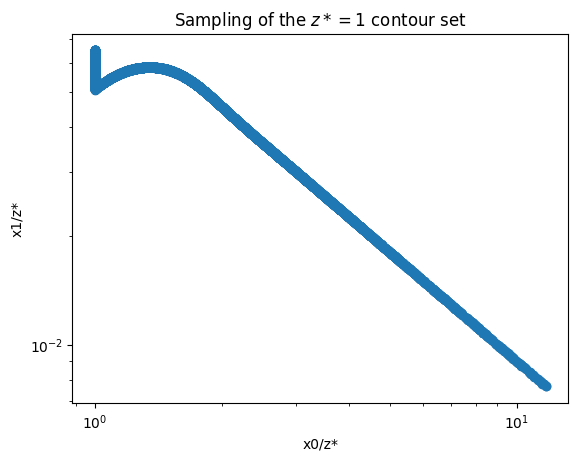

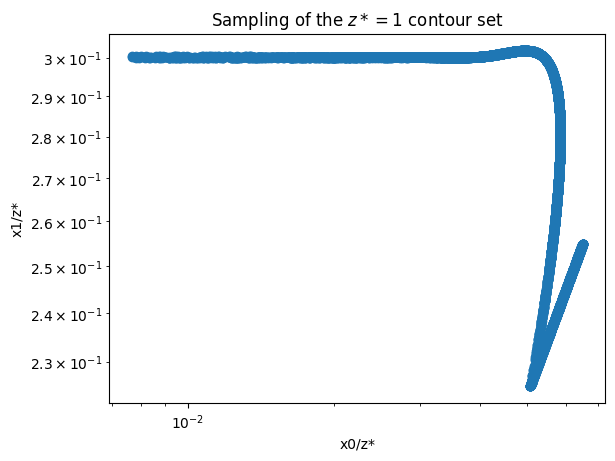

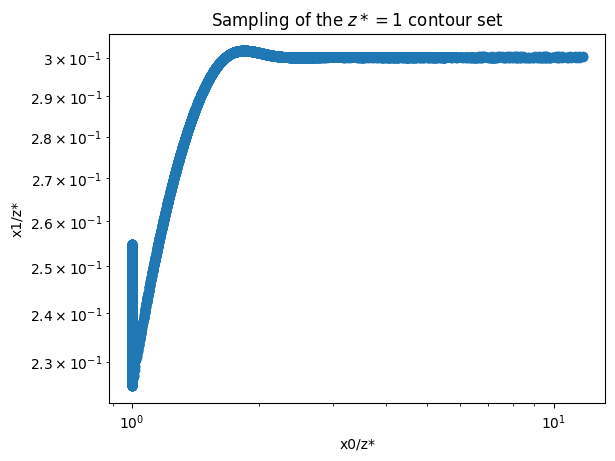

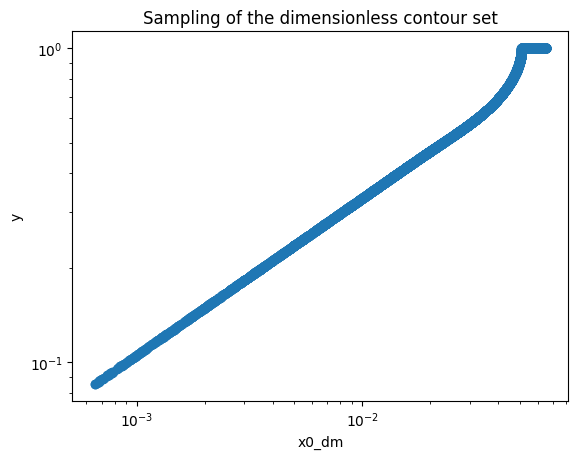

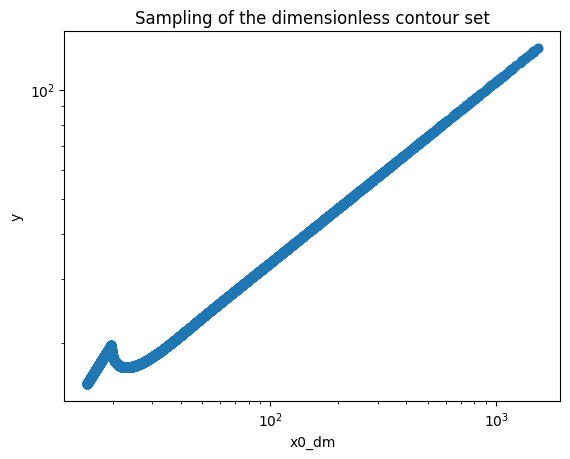

In [5]:
#1 Contours d1H Sets

def contour_d1H (data):
    plt.scatter(data['x0'], data['x1'])
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("x0/z*")
    plt.ylabel("x1/z*")
    plt.title("Sampling of the $z*=1$ contour set")
    plt.show()
    
def contour_dm (data):
    plt.scatter(data['x0'], data['y'])
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("x0_dm")
    plt.ylabel("y")
    plt.title("Sampling of the dimensionless contour set")
    plt.show()

#d1H Set 1
contour_d1H(data_d1H_1_scaled)
#d1H Set2
contour_d1H(data_d1H_2_scaled)

#d1H Set2
contour_d1H(data_d1H_3_scaled)

#DM Set 1
contour_dm(data_dm_1)
#DM Set 2
contour_dm(data_dm_2)

interactive(children=(FloatSlider(value=0.0, description='w0', max=0.2, min=-0.2, step=0.001), FloatSlider(val…

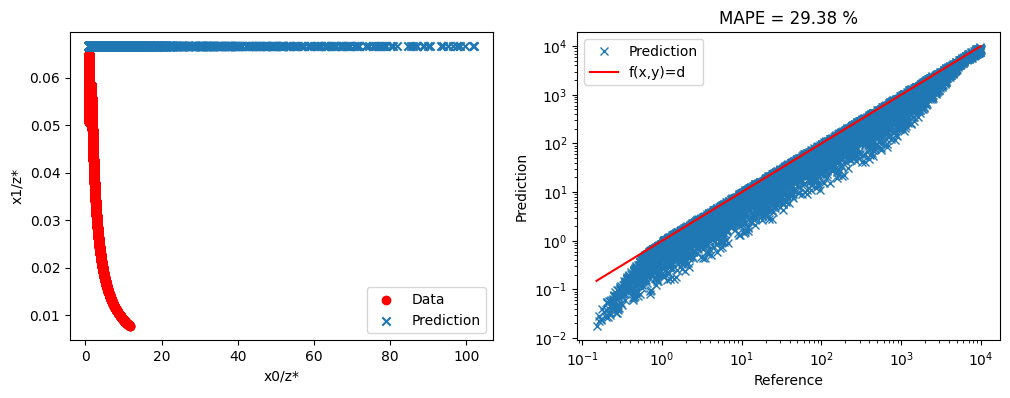

In [6]:
def linear_network(x0, x1, W):
    """
    Linear fit of a response variable dependent 
    on explanatory variables x0, x1 weighted by W.
    """
    
    f = W[0]*x0 + W[1]*x1
    
    return x0/f, x1/f, f

def mape(prediction, truth):
    return 100 * np.mean(np.abs((prediction - truth) / truth))

def fit_and_validate(W, data, data_scaled, network):
    """
    input:
    W           array of weights
    data        input data
    data_scaled rescaled input data
    network     a function e.g. "linear_network" implemented above
    
    output: 
    up to you..
    """

    # Predict the hypothenuse by evaluating the provided network on the provided data.
    x0, x1, f = network(data['x0'], data['x1'], W)
    # Compute the mape.
    accuracy = mape(f, data['z*'])

    # Recreate the figure with the two plots shown above
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.scatter(data_scaled.x0, data_scaled.x1, color="red", label="Data")
    ax1.scatter(x0, x1, marker="x", label="Prediction")
    ax1.set_xlabel("x0/z*")
    ax1.set_ylabel("x1/z*")
    ax1.legend()
    
    # Verify the prediction using the provided labels.
    ax2.loglog(data['z*'], f, marker="x", ls='', label="Prediction")
    # Create the diagonal line.
    z = [data['z*'].min(), data['z*'].max()]
    ax2.plot(z, z, color='r', label = "f(x,y)=d")
    # Report the error in the plot title.
    ax2.set_title(f"MAPE = {accuracy:.2f} %" )
    ax2.set_xlabel("Reference")
    ax2.set_ylabel("Prediction")
    ax2.legend()


%matplotlib inline
import ipywidgets as ip

def interactive_fit(w0, w1):
    fit_and_validate([w0, w1], data_d1H_1, data_d1H_1_scaled, linear_network)

ip.interact(interactive_fit, w0=(-0.2, 0.2, 0.001), w1=(10.00, 20.00, 0.001));

#Best at w0 = 0.18 ; w1 = 13.48 (6.12%)

**Generalized Linear Regression**

interactive(children=(FloatSlider(value=0.0, description='w0', max=0.2, min=-0.2, step=0.001), FloatSlider(val…

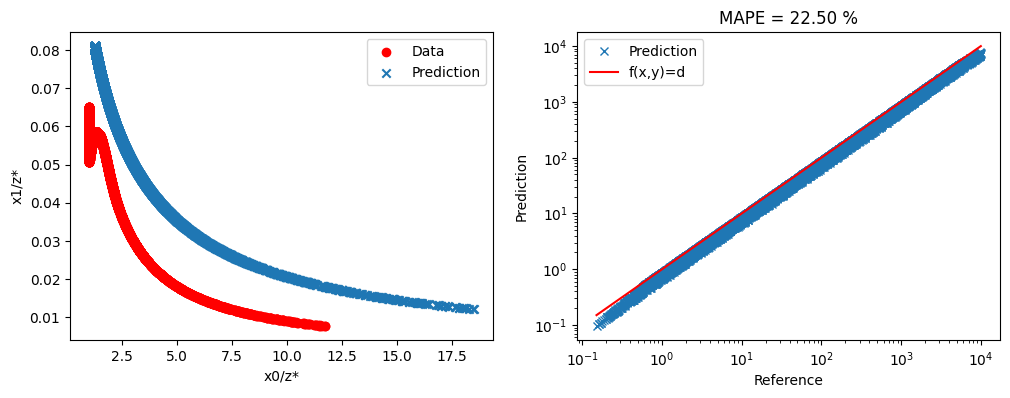

In [7]:
def generalized_linear_network(x0, x1, W):
    f = W[0]*x0 + W[1]*x1 + W[2] * np.sqrt(x0 * x1)
    
    return x0/f, x1/f, f

%matplotlib inline
import ipywidgets as ip

def interactive_fit(w0, w1, w2):
    fit_and_validate([w0, w1, w2], data_d1H_1, data_d1H_1_scaled, generalized_linear_network)

ip.interact(interactive_fit, w0=(-0.20, 0.20, 0.001), w1=(-1.00, 10.00, 0.01), w2=(-1.00, 5.00, 0.01));

#w0 = -0.01; w1 = 2.05; w2 = 3.20

## Building blocks for neural networks

In [8]:
# Network weight initialization function
# Check the assignment text for a different way to initialize your weights.

def init_weights(input_dim, output_dim):
    return np.random.uniform(-1.0, 1.0, (input_dim, output_dim))

In [9]:
def init_weights_2(input_dim, output_dim, sigma=0.1):
    return np.random.normal(0.0, sigma, (input_dim, output_dim))

In [10]:
# Activation functions

def relu(input):
    return np.maximum(0, input)

In [11]:
# Loss functions

def msre(input, target):
    return np.square((target - input) / target).mean()

In [12]:
# Predict using a trained set of model weights.

def predict(input, weights):
    [w1, w2] = weights
    return relu(input @ w1) @ w2

def predict_dm(input, weights):
    [w1, w2] = weights
    return relu(input @ w1 + 1) @ w2

In [13]:
#Data split
test_d1H_1 = data_d1H_1.sample(int(data_d1H_1.shape[0]/5))#get a random 20% sample of the data set
train_d1H_1 = data_d1H_1.drop(test_d1H_1.index)

test_dm_1 = data_dm_2.sample(int(data_dm_2.shape[0]/5))#get a random 20% sample of the data set
train_dm_1 = data_dm_2.drop(test_dm_1.index)

#Convert to numpy
train_np_dh = train_d1H_1.to_numpy()
test_np_dh = test_d1H_1.to_numpy()

train_np_dm = train_dm_1.to_numpy()
test_np_dm = test_dm_1.to_numpy()

print(train_np_dh)

[[7.14848180e+02 4.42576611e+01 7.14848180e+02]
 [3.77594704e+01 1.25461343e+00 2.29850107e+01]
 [4.79329682e+03 2.28159261e+02 3.98690302e+03]
 ...
 [2.42885320e+03 3.66830682e+01 9.95057284e+02]
 [2.73414556e+03 5.57446394e+01 1.29843200e+03]
 [7.88314976e+00 2.23853583e-01 4.40283139e+00]]


In [14]:
def train_model_test(
    num_neurons, epochs, train, test, lr = 10e-5
):
    w1 = init_weights_2(2, num_neurons)
    w2 = init_weights_2(num_neurons, 1)

    train_loss = []
    test_loss = []

    for epoch in range(epochs):
        epoch_loss = 0
            
        for entry in train:

            entry = entry.reshape(1, -1) # ADDED EXTRA
            # Split the label from the input
            [x0, y] = np.split(entry, [-1], axis=1)

            # Forward pass
            z1 = x0 @ w1
            x1 = relu(z1)

            z2 = x1 @ w2

            # Compute error
            loss = msre(z2, y)
            epoch_loss += loss

            # TODO: Implement backward pass.
                #w2 = w2 - lr*np.transpose(2*(-y+z2)@x1/(y*y))
                #w1 = w1 - lr*np.transpose(x0@(np.heaviside(np.transpose(z1), 1)*w2@(-y+z2)/(y*y)))
            dz2 = 2*(-y+z2)/(y*y)
            dw2 = dz2@x1

            dx1 = w2  @ (-y+z2)/(y*y)*2
            dz1 = dx1*np.heaviside(np.transpose(z1), 0)
            dw1 = dz1 @ x0
            
            w1 = w1 - lr*np.transpose(dw1)
            w2 = w2 - lr*np.transpose(dw2) 
            

        #TODO: Compute total loss for the epoch
        loss_this_epoch = np.divide(epoch_loss, len(train)) # Replace nan with your code
        # Add the loss for this epoch to the list of losses
        train_loss.append(loss_this_epoch)
        
        # Compute and store test loss.
        pred = predict(test[:, :2], [w1, w2])
        test_loss.append(msre(pred[:, 0], test[:, 2]))

    return [[train_loss, test_loss], [w1, w2]]



In [15]:
# Function to train a simple 2-N-1 model.
# NOTE: This function expects numpy matrices for the train and test data.
#       If your train and test data is stored in pandas dataframes you 
#       can convert using the `.to_numpy()` function.

def train_model_dh(
    num_neurons, epochs, train, test, lr = 1e-6 , batch_size = 10
):
    w1 = init_weights_2(2, num_neurons)
    w2 = init_weights_2(num_neurons, 1)

    train_loss = []
    test_loss = []

    for epoch in range(epochs):
        epoch_loss = 0
            
        train_index = 0
        train_end = 0
        while (train_end+1 != train.shape[0]):
            
            train_end = train_index + batch_size
            if(train_end >= train.shape[0]):
                train_end = train.shape[0]-1
             
            # Split the label from the input
            
            batch = train[train_index:train_end ]
            train_index += batch_size
            [x0, y] = np.split(batch, [-1], axis=1)
            # Forward pass
            z1 = x0 @ w1
            x1 = relu(z1)

            z2 = x1 @ w2

            # Compute error
            loss = msre(z2, y)
            epoch_loss += loss

            # TODO: Implement backward pass.
                           #w2 = w2 - lr*np.transpose(2*(-y+z2)@x1/(y*y))
                #w1 = w1 - lr*np.transpose(x0@(np.heaviside(np.transpose(z1), 1)*w2@(-y+z2)/(y*y)))
            dz2 = 2*(-y+z2)/(y*y)
            #print("dz2.T shape",dz2.T.shape,"shape x1",x1.shape)
            #print("w2 shape",w2.shape,"shape -y...",((-y+z2)/(y*y)*2).shape)
            
            dw2 = dz2.T@x1

            dx1 = w2  @ ((-y+z2)/(y*y)*2).T
            #print("dx1 shape",dx1.shape,"shape heavy side",(np.heaviside(np.transpose(z1), 0)).shape)
            
            dz1 = dx1*np.heaviside(np.transpose(z1), 0)
            #print("dz1 shape",dz1.shape,"shape x0",x0.shape)
            dw1 = dz1 @ x0
            w1 = w1 - lr*np.transpose(dw1)
            w2 = w2 - lr*np.transpose(dw2) 
            

        #TODO: Compute total loss for the epoch
        loss_this_epoch =  np.divide(epoch_loss, len(train)) # Replace nan with your code
        # Add the loss for this epoch to the list of losses
        train_loss.append(loss_this_epoch)
        
        # Compute and store test loss.
        pred = predict(test[:, :2], [w1, w2])
        test_loss.append(msre(pred[:, 0], test[:, 2]))

    return [[train_loss, test_loss], [w1, w2]]

In [29]:
#DIMENSIONLESS VERSION

# Function to train a simple 2-N-1 model.
# NOTE: This function expects numpy matrices for the train and test data.
#       If your train and test data is stored in pandas dataframes you 
#       can convert using the `.to_numpy()` function.

def train_model_dm(
    num_neurons, epochs, train, test, lr = 5e-5 , batch_size = 10
):
    w1 = init_weights(1, num_neurons)
    w2 = init_weights(num_neurons, 1)

        
    train_loss = []
    test_loss = []

    for epoch in range(epochs):
        epoch_loss = 0
       
        train_index = 0
        train_end = 0
        while (train_end+1 != train.shape[0]):
            
            train_end = train_index + batch_size
            if(train_end >= train.shape[0]):
                train_end = train.shape[0]-1
             
            # Split the label from the input
            batch = train[train_index:train_end ] 
            train_index += batch_size
            # Split the label from the input
            [x0, y] = np.split(batch, [-1], axis=1)
            
            # Forward pass
            
            z1 = x0 @ w1 + 1
            x1 = relu(z1)

            #z1 = x0 @ w1
            #x1 = relu(z1)

            z2 = x1 @ w2 + 1

            # Compute error
            loss = msre(z2, y)
            epoch_loss += loss

            # TODO: Implement backward pass.


            dz2 = 2*(-y+z2)/(y*y)
            #print("dz2.T shape",dz2.T.shape,"shape x1",x1.shape)
            #print("w2 shape",w2.shape,"shape -y...",((-y+z2)/(y*y)*2).shape)
            
            dw2 = dz2.T@x1

            dx1 = w2  @ ((-y+z2)/(y*y)*2).T
            #print("dx1 shape",dx1.shape,"shape heavy side",(np.heaviside(np.transpose(z1), 0)).shape)
            
            dz1 = dx1*np.heaviside(np.transpose(z1), 0)
            #print("dz1 shape",dz1.shape,"shape x0",x0.shape)
            dw1 = dz1 @ x0
            w1 = w1 - lr*np.transpose(dw1)
            w2 = w2 - lr*np.transpose(dw2) 

            
        #TODO: Compute total loss for the epoch
        loss_this_epoch = np.divide(epoch_loss, len(train)) # Replace nan with your code
        # Add the loss for this epoch to the list of losses
        train_loss.append(loss_this_epoch)
        
        # Compute and store test loss.
    
        
        pred = predict_dm(test[: , :1], [w1, w2])
        test_loss.append(msre(pred[:, 0], test[:, 1]))

    return [[train_loss, test_loss], [w1, w2]]

In [17]:
def train_model_dh_deep(
    num_neurons, epochs, train, test, lr = 10e-4
):
    w1 = init_weights_2(2, num_neurons)
    w2 = init_weights_2(num_neurons, num_neurons)
    w3 = init_weights_2(num_neurons, 1)

    train_loss = []
    test_loss = []

    for epoch in range(epochs):
        epoch_loss = 0
            
        train_index = 0
        train_end = -1
        while (train_end != train.shape[0]):
            
            train_end = train_index + batch_size
            if(train_end >= train.shape[0]):
                train_end = train.shape[0]
             
            # Split the label from the input
            batch = train[train_index:train_end ] 
            train_index += batch_size
            # Split the label from the input
            [x0, y] = np.split(entry, [-1], axis=1)

            # Forward pass
            z1 = x0 @ w1
            x1 = relu(z1)

            z2 = x1 @ w2
            x2 = relu(z2)
            
            z3 = x2 @ w3

            # Compute error
            loss = msre(z3, y)
            epoch_loss += loss

            # TODO: Implement backward pass.
            N = z3.size
            dz3 = (2.0 / N) * (z3 - y) / (y * y)
            dw3 = x2.T @ dz3
            dx2 = dz3 @ w3.T
            dz2 = dx2 * (z2 > 0)   # dL/dz2 for MSR
            dw2 = x1.T @ dz2                       # (num_neurons, 1)
            dx1 = dz2 @ w2.T                       # (1, num_neurons)
            dz1 = dx1 * (z1 > 0)                   # ReLU derivative
            dw1 = x0.T @ dz1                       # (2, num_neurons)

            w3 = w3 - lr * dw3
            w2 = w2 - lr * dw2
            w1 = w1 - lr * dw1

        #TODO: Compute total loss for the epoch
        loss_this_epoch = np.divide(epoch_loss, len(train)) # Replace nan with your code
        # Add the loss for this epoch to the list of losses
        train_loss.append(loss_this_epoch)
        
        # Compute and store test loss.
        pred = predict(test[:, :2], [w1, w2])
        test_loss.append(msre(pred[:, 0], test[:, 2]))
    
    return [[train_loss, test_loss], [w1, w2, w3]]


In [18]:

def plot_trainloss(trainloss,testloss, titel):
    epochs = np.arange(len(trainloss))

    plt.plot(epochs, trainloss, label="Train Loss")
    plt.yscale("log")
    plt.plot(epochs, testloss, label="Test Loss")
    plt.title(titel)
    plt.xlabel("Epoch")
    plt.ylabel("MSRE Loss")
    plt.yscale("log")
    plt.legend()

    plt.show()



In [19]:
def total_msre_dh(array_of_waits,predict_function,x0,y,msre):
    z = predict_function(x0,array_of_waits) 
    msre = msre(z,y)
    average_msre = np.sum(msre)/msre.size 
    return msre

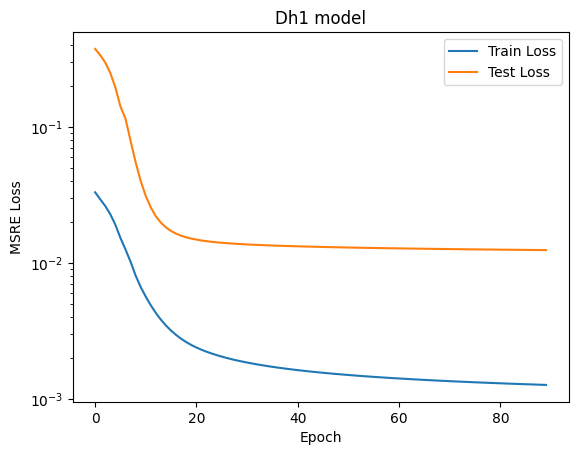

In [20]:
#Train the model d1H
epochs = 90
neurons = 300
learn_rate = 1e-3
batch_size = 10
[[trainloss_dh, testloss_dh], waits_dh] = train_model_dh(
    neurons,
    epochs , 
    train_np_dh, 
    test_np_dh,
    learn_rate)
plot_trainloss(trainloss_dh,testloss_dh,"Dh1 model")


In [21]:
print(data_d1H_1);
#print(data_d1H_1.to_numpy()[:,0:1])
x0_tot = data_d1H_1.to_numpy()[:,0:2]
print(x0_tot)
y_tot = data_d1H_1.to_numpy()[:,-1]
print(y_tot)
tot_msre =total_msre_dh(waits_dh,predict,x0_tot,y_tot,msre)
print("total error" , tot_msre)

               x0          x1           z*
0      714.848180   44.257661   714.848180
1       37.759470    1.254613    22.985011
2     4793.296822  228.159261  3986.903017
3      252.695524    2.813362    88.865519
4        5.221472    0.291580     5.221472
...           ...         ...          ...
8995   924.290082   43.406544   753.447106
8996     1.905777    0.082902     1.419707
8997  2428.853204   36.683068   995.057284
8998  2734.145563   55.744639  1298.432000
8999     7.883150    0.223854     4.402831

[9000 rows x 3 columns]
[[7.14848180e+02 4.42576611e+01]
 [3.77594704e+01 1.25461343e+00]
 [4.79329682e+03 2.28159261e+02]
 ...
 [2.42885320e+03 3.66830682e+01]
 [2.73414556e+03 5.57446394e+01]
 [7.88314976e+00 2.23853583e-01]]
[ 714.84818041   22.9850107  3986.90301738 ...  995.05728369 1298.43199955
    4.40283139]
total error 901775.6074756543


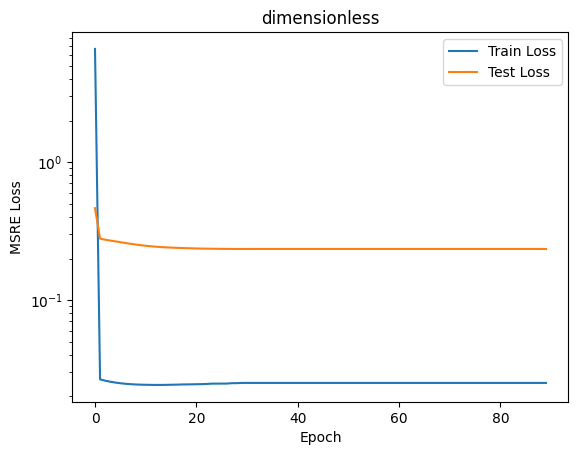

In [31]:
#Train the model Dimensionless
[[trainloss_dm, testloss_dm], [w1_dm, w2_dm]] = train_model_dm(
    neurons, 
    epochs, 
    train_np_dm,
    test_np_dm,
    learn_rate,
    batch_size)
plot_trainloss(trainloss_dm,testloss_dm,"dimensionless")


In [ ]:
#Train model deep
[[trainloss_dm, testloss_dm], [w1_dm, w2_dm]] = train_model_dh_deep(
    neurons, 
    epochs, 
    train_np_dm, 
    test_np_dm
    learn_rate,
    batch_size)
plot_trainloss(trainloss_dm,testloss_dm)

In [ ]:
#Predict Shallow
def predict_all_dh(data, weights):
    X = data.iloc[:, :2].to_numpy()    #convert pd df to numpy       
    return predict_dh(X, weights)   
prediction_dh = predict_all_dh(data_bench_dh, [w1_dh, w2_dh])
prediction_test = predict_all_dh(data_d1H_1, [w1_dh, w2_dh])
#print(len(predict_dh))
#print("data_d1H_1 rows:", len(data_d1H_1))
#X = data_d1H_1.iloc[:, :2].to_numpy()
#print("X shape:", X.shape)
#prediction_np = predict(X, [w1_dh, w2_dh])
#print("pred shape:", pred.shape)

model_test = submission = pd.DataFrame({
    "id": range(len(data_d1H_1)),
    "prediction": prediction_test.ravel()
})

submission = pd.DataFrame({
    "id": range(len(data_bench_dh)),
    "prediction": prediction_dh.ravel()
})

#print(submission)
submission.to_csv("predictions.csv", index=False)
print(model_test)
#print(model_test['prediction'] - data_train['z*'])


In [ ]:
#Predict Deep
def predict_all_deep(data, weights):
    X = data.iloc[:, :2].to_numpy()    #convert pd df to numpy       
    return predict_deep(X, weights)   
prediction_dh = predict_all(data_bench_dh, [w1_dh, w2_dh, w3_dh])
prediction_test = predict_all(data_d1H_1, [w1_dh, w2_dh, w3_dh])
#print(len(predict_dh))
#print("data_d1H_1 rows:", len(data_d1H_1))
#X = data_d1H_1.iloc[:, :2].to_numpy()
#print("X shape:", X.shape)
#prediction_np = predict(X, [w1_dh, w2_dh])
#print("pred shape:", pred.shape)

model_test = submission = pd.DataFrame({
    "id": range(len(data_d1H_1)),
    "prediction": prediction_test.ravel()
})

submission = pd.DataFrame({
    "id": range(len(data_bench_dh)),
    "prediction": prediction_dh.ravel()
})

#print(submission)
submission.to_csv("predictions.csv", index=False)
print(model_test)
#print(model_test['prediction'] - data_train['z*'])
error = []
for i in range(9000):
    error.append(msre(prediction_test[i], z[i]))

print (sum(error)/len(error))

In [ ]:
#Final Predict Function
#predict_dh.to_csv('out.csv')

In [ ]:
# Function to visualize the learned model behavior.
#data_predicted=predict_final(data_d1H_1['x0'], data_d1H_1['x1'], ww1, ww2)

#def plot_behavior(data, pred):
    # TODO: Plot the predicted one-contour/dimensionless relation vs the truth.

In [ ]:
# TODO: Train your best neural network using sliders, grid search, or backpropagation. 
#       This network is allowed to have more than one intermediate layer.